In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
df = pd.read_csv('sample_data/Food_Items_Calories.csv')

In [21]:
df.shape

(180, 5)

In [22]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

In [23]:
df.head()

,Food Item,Weight/Volume(g/ml),Calories,Food Group
0,Rice (Brown),100,353.7,Cereals and Millets
1,Rice Parboiled,100,351.5,Cereals and Millets
2,Rice Raw milled,100,356.3,Cereals and Millets
3,Wheat whole,100,321.9,Cereals and Millets
4,Wheat flour,100,320.2,Cereals and Millets


In [24]:
import sqlite3

# Создаем соединение с временной базой данных в памяти
conn = sqlite3.connect(':memory:')

# Загружаем DataFrame в таблицу SQL
df.to_sql('food_items', conn, index=False, if_exists='replace')

# Пример SQL-запроса с оконной функцией и ранжированием продуктов по калорийности
sql_query = """
SELECT
    "Food Group",
    "Food Item",
    "Calories",
    AVG("Calories") OVER(PARTITION BY "Food Group") AS avg_group_calories,
    RANK() OVER(PARTITION BY "Food Group" ORDER BY "Calories" DESC) AS rank_in_group
FROM food_items
ORDER BY "Food Group", rank_in_group
"""

sql_result = pd.read_sql_query(sql_query, conn)
print("Результат SQL-запроса (первые 10 строк):")
sql_result.head(10)

Результат SQL-запроса (первые 10 строк):


,Food Group,Food Item,Calories,avg_group_calories,rank_in_group
0,Cereals and Millets,Rice Raw milled,356.3,338.7375,1
1,Cereals and Millets,"Amaranth seed, Black",356.1,338.7375,2
2,Cereals and Millets,Rice (Brown),353.7,338.7375,3
3,Cereals and Millets,Rice flakes,353.7,338.7375,3
4,Cereals and Millets,Refined flour,351.8,338.7375,5
5,Cereals and Millets,Rice Parboiled,351.5,338.7375,6
6,Cereals and Millets,Bajra,347.9,338.7375,7
7,Cereals and Millets,Bulgar wheat,341.7,338.7375,8
8,Cereals and Millets,Jowar,334.1,338.7375,9
9,Cereals and Millets,Wheat semolina,333.6,338.7375,10


/tmp/ipykernel_6768/3938631581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cal.values, y=avg_cal.index, palette='Blues_r')


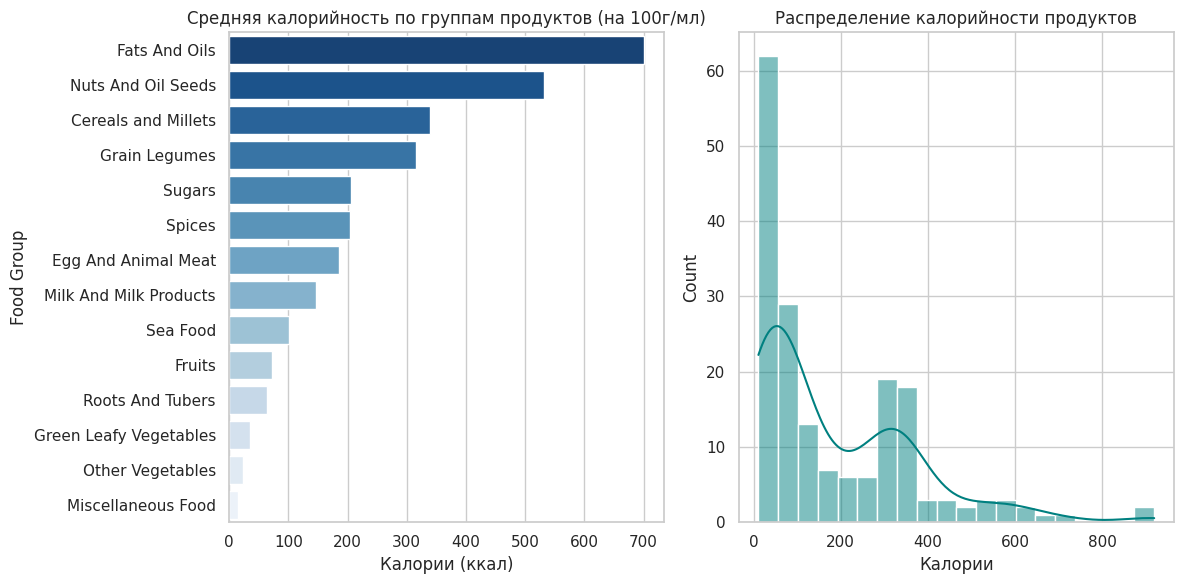

In [25]:
plt.figure(figsize=(12, 6))

# График 1: Топ категорий по средней калорийности
plt.subplot(1, 2, 1)
avg_cal = df.groupby('Food Group')['Calories'].mean().sort_values(ascending=False)
sns.barplot(x=avg_cal.values, y=avg_cal.index, palette='Blues_r')
plt.title('Средняя калорийность по группам продуктов (на 100г/мл)')
plt.xlabel('Калории (ккал)')

# График 2: Распределение калорий во всем датасете
plt.subplot(1, 2, 2)
sns.histplot(df['Calories'], kde=True, color='teal', bins=20)
plt.title('Распределение калорийности продуктов')
plt.xlabel('Калории')

plt.tight_layout()
plt.show()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Рассчитаем удельные показатели
df['Calories_per_gram'] = df['Calories'] / df['Weight/Volume(g/ml)']

# 2. NLP: Применяем TF-IDF векторизацию для названий продуктов
tfidf = TfidfVectorizer(stop_words='english', max_features=50)
tfidf_matrix = tfidf.fit_transform(df['Food Item'])

# Преобразуем признак текста в DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
print("Форма матрицы текстовых признаков (TF-IDF):", tfidf_df.shape)
tfidf_df.head()

Форма матрицы текстовых признаков (TF-IDF): (180, 50)


,amaranth,apple,beans,bengal,black,brown,buffalo,bulgar,cabbage,cane,capsicum,cauliflower,chicken,chillies,cho,chops,coconut,cow,cumin,dal,dried,dry,egg,fenugreek,fish,flour,fresh,fruit,gourd,gram,green,leaves,milk,nut,pea,peas,pork,potato,radish,raw,red,rice,seed,seeds,sheep,shoulder,skinless,sweet,wheat,white
0,0.0,0.0,0.0,0.0,0.0,0.692633,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.721290,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.0,0.707107,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.756655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.653815,0.0


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Исключаем редкие категории
counts = df['Food Group'].value_counts()
valid_groups = counts[counts >= 2].index
df_ml = df[df['Food Group'].isin(valid_groups)].copy()

# 2. TF-IDF для текста
tfidf = TfidfVectorizer(stop_words='english', max_features=30)
X_text = tfidf.fit_transform(df_ml['Food Item']).toarray()

# 3. Масштабирование чисел
scaler = StandardScaler()
X_num = scaler.fit_transform(df_ml[['Weight/Volume(g/ml)', 'Calories']])

# 4. Объединение признаков
X = np.hstack([X_text, X_num])
y = df_ml['Food Group']

# 5. Разделение выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)